In [2]:
import seaborn as sns
import pandas as pd
import numpy as np

# Load Titanic dataset
df = sns.load_dataset('titanic')

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Remove deck column because it has too many missing values
df = df.drop(columns=['deck'])

# Fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Target variable
y = df['survived']

# Feature variables
X = df.drop(columns=['survived', 'alive'])

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Survival Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Survival Distribution:")
print(y_test.value_counts(normalize=True))

Training Set Shape: (712, 12)
Testing Set Shape: (179, 12)

Training Survival Distribution:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing Survival Distribution:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


The Titanic dataset has a class imbalance, with approximately 62% of passengers not surviving and 38% surviving. Stratified splitting ensures that both the training and testing datasets maintain approximately the same proportion of survived and non-survived passengers. This is important because it provides a more representative dataset for training and evaluating the classification models.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical features
numeric_features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

# Categorical features
categorical_features = [
    'sex',
    'embarked',
    'class',
    'who',
    'adult_male',
    'embark_town',
    'alone'
]

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Complete preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data without fitting again
X_test_processed = preprocessor.transform(X_test)

print("Training data preprocessing completed!")
print("Testing data preprocessing completed!")

print("\nProcessed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Training data preprocessing completed!
Testing data preprocessing completed!

Processed Training Shape: (712, 23)
Processed Testing Shape: (179, 23)


Missing values in numeric columns are handled using median imputation, while missing values in categorical columns are handled using the most frequent value. The categorical columns sex and embarked are encoded using One-Hot Encoding, and numeric features are scaled using StandardScaler. All preprocessing steps are fitted only on the training data and are applied to the test data using transform-only mode to prevent data leakage.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Logistic Regression Pipeline
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Decision Tree Pipeline
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Random Forest Pipeline
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train all models on the same training data
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")
print("Decision Tree trained successfully!")
print("Random Forest trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


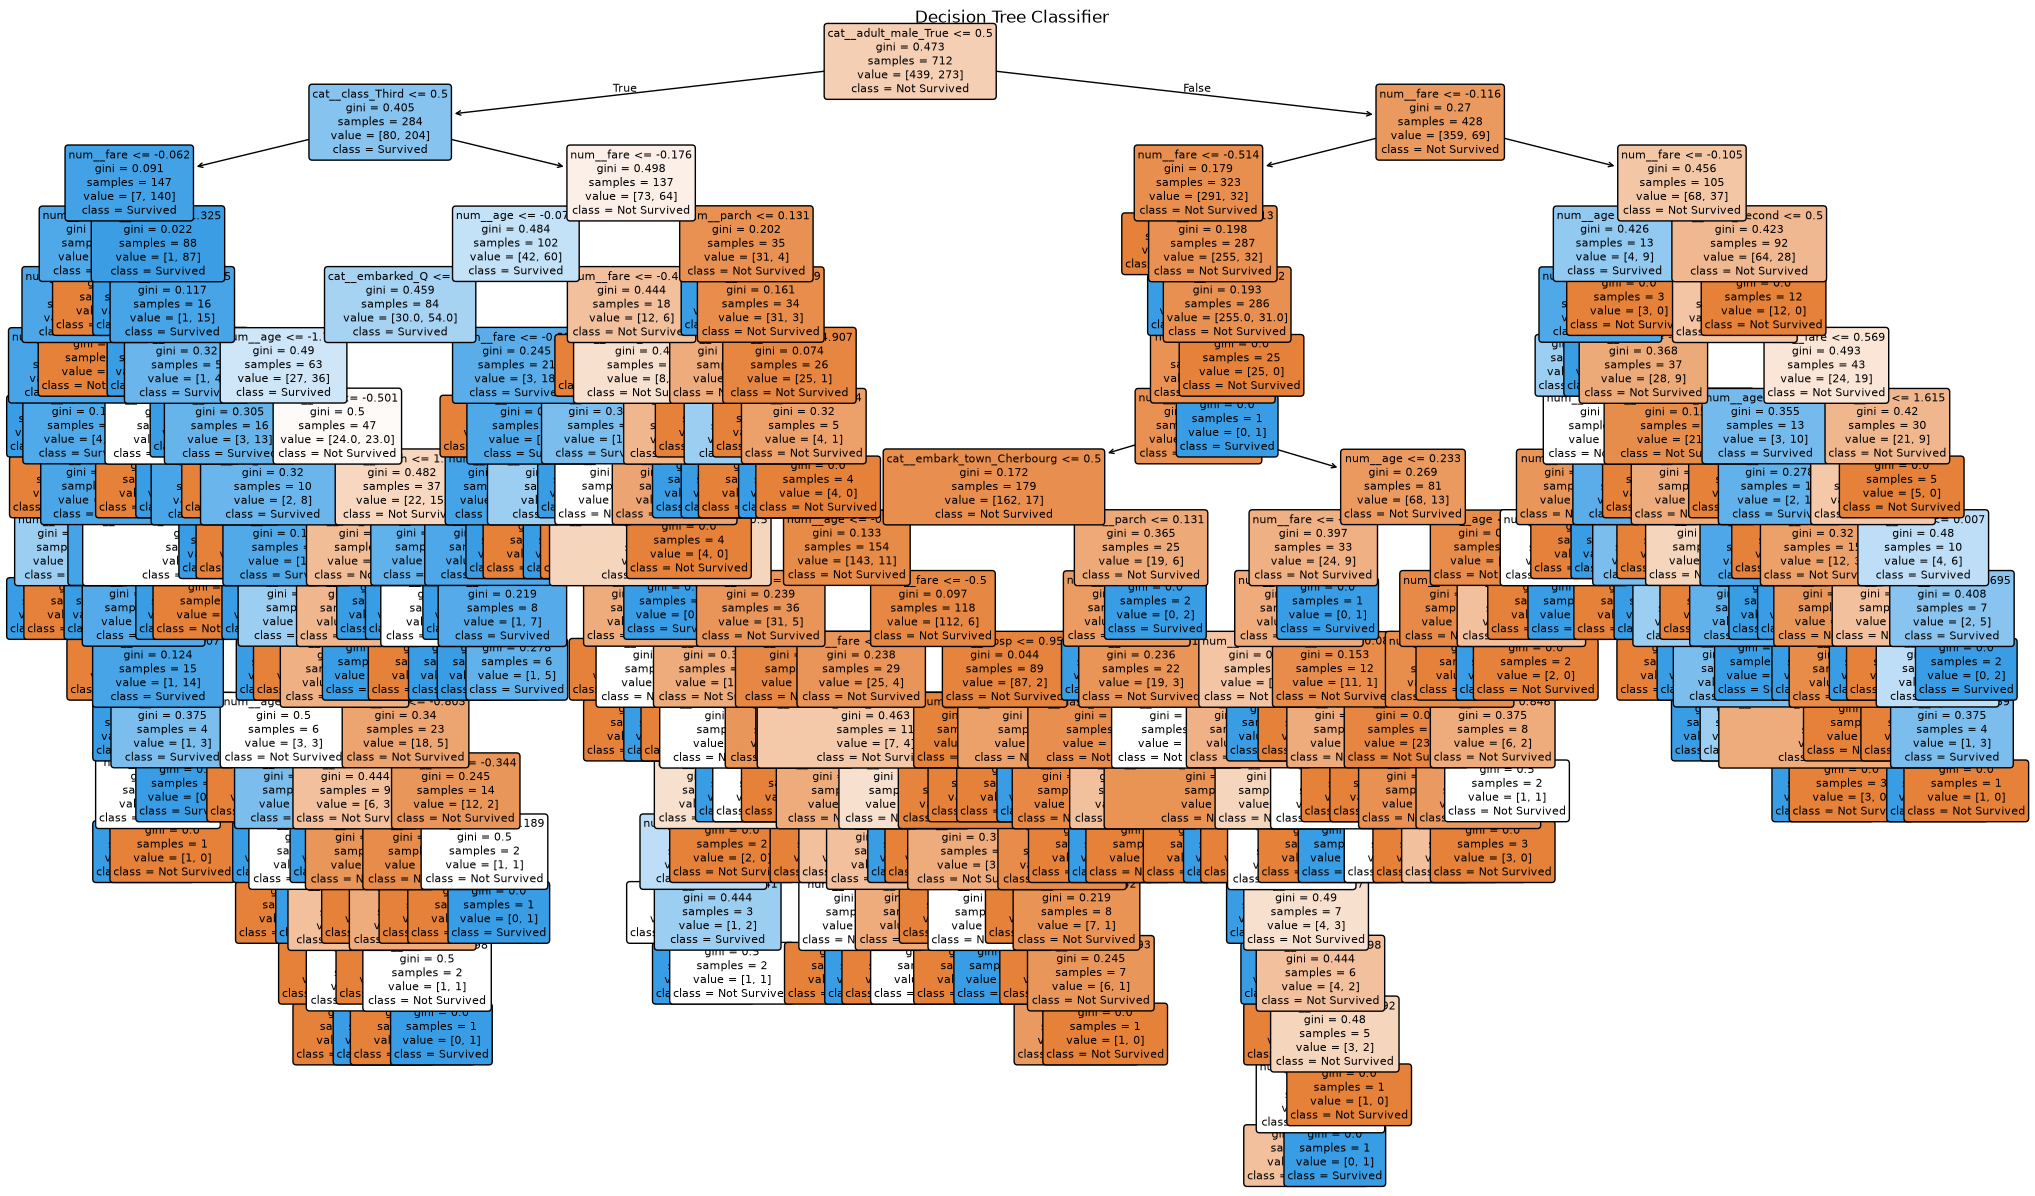

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get the trained Decision Tree
tree = decision_tree_model.named_steps['model']

# Plot the Decision Tree
plt.figure(figsize=(25, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.show()

In [8]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd

In [9]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions for ROC/AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    })

print("Evaluation completed successfully!")

Evaluation completed successfully!


In [10]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Confusion Matrix:")
    print(cm)


Logistic Regression Confusion Matrix:
[[98 12]
 [18 51]]

Decision Tree Confusion Matrix:
[[93 17]
 [18 51]]

Random Forest Confusion Matrix:
[[96 14]
 [17 52]]


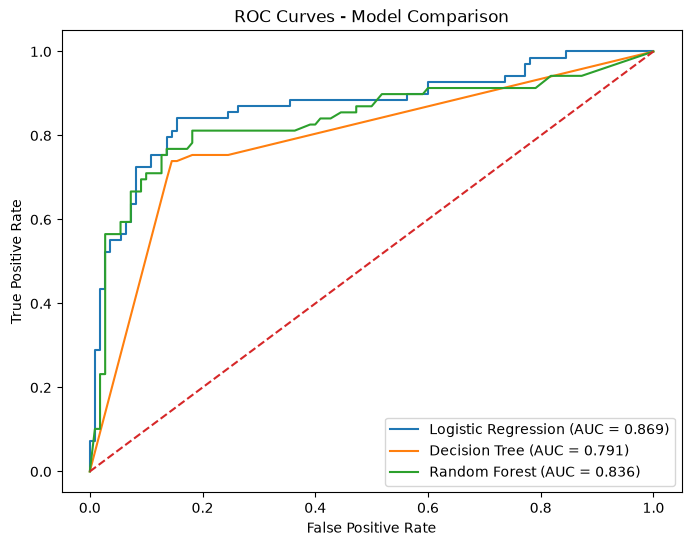

In [11]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()

plt.show()

In [12]:
comparison_table = pd.DataFrame(results)

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.832402,0.809524,0.739130,0.772727,0.868643
1,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.790580
2,Random Forest,0.826816,0.787879,0.753623,0.770370,0.836298


In [13]:
print("Overall Class Balance:")

class_balance = y.value_counts()
class_percentage = y.value_counts(normalize=True) * 100

print("\nClass Counts:")
print(class_balance)

print("\nClass Percentage:")
print(class_percentage)

Overall Class Balance:

Class Counts:
survived
0    549
1    342
Name: count, dtype: int64

Class Percentage:
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_processed, y_train)

baseline_pred = baseline_model.predict(X_test_processed)

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("BASELINE MODEL (No Imbalance Handling)")
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1 Score:", baseline_f1)

BASELINE MODEL (No Imbalance Handling)
Precision: 0.8095238095238095
Recall: 0.7391304347826086
F1 Score: 0.7727272727272727


In [15]:
# Logistic Regression with class_weight='balanced'

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

balanced_model.fit(X_train_processed, y_train)

balanced_pred = balanced_model.predict(X_test_processed)

balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

print("CLASS WEIGHT = BALANCED")

print("Precision:", balanced_precision)
print("Recall:", balanced_recall)
print("F1 Score:", balanced_f1)

CLASS WEIGHT = BALANCED
Precision: 0.7671232876712328
Recall: 0.8115942028985508
F1 Score: 0.7887323943661971


In [18]:
from imblearn.over_sampling import SMOTE

In [19]:
# Apply SMOTE only to the training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [20]:
# Logistic Regression trained on SMOTE-balanced training data

smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

# Predictions on the ORIGINAL test data
smote_pred = smote_model.predict(X_test_processed)

# Calculate metrics
smote_precision = precision_score(y_test, smote_pred)
smote_recall = recall_score(y_test, smote_pred)
smote_f1 = f1_score(y_test, smote_pred)

print("SMOTE MODEL RESULTS")
print("Precision:", smote_precision)
print("Recall:", smote_recall)
print("F1 Score:", smote_f1)

SMOTE MODEL RESULTS
Precision: 0.7631578947368421
Recall: 0.8405797101449275
F1 Score: 0.8


In [21]:
imbalance_results = pd.DataFrame({
    "Method": [
        "Baseline (No Handling)",
        "Class Weight = Balanced",
        "SMOTE Oversampling"
    ],
    "Precision": [
        0.8095238095238095,
        0.7671232876712328,
        0.7631578947368421
    ],
    "Recall": [
        0.7391304347826086,
        0.8115942028985508,
        0.8405797101449275
    ],
    "F1 Score": [
        0.7727272727272727,
        0.7887323943661971,
        0.8
    ]
})

imbalance_results

,Method,Precision,Recall,F1 Score
0,Baseline (No Handling),0.809524,0.739130,0.772727
1,Class Weight = Balanced,0.767123,0.811594,0.788732
2,SMOTE Oversampling,0.763158,0.840580,0.800000


## Imbalance Handling Conclusion

The dataset has a moderate class imbalance, with approximately 61.6% not-survived passengers and 38.4% survived passengers. The baseline model achieved the highest precision (0.810), but it had the lowest recall (0.739), meaning it missed more passengers who actually survived.

Using `class_weight='balanced'` improved recall to 0.812 and increased the F1 score to 0.789. SMOTE oversampling produced the highest recall (0.841) and the highest F1 score (0.800), making it the best overall imbalance-handling strategy because it provided the strongest balance between precision and recall.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest with OOB enabled
rf_oob = RandomForestClassifier(
    oob_score=True,
    random_state=42
)

# Hyperparameters to tune
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_oob,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit GridSearch only on training data
grid_search.fit(X_train_processed, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

print("\nOut-of-Bag (OOB) Score:")
print(best_rf.oob_score_)

Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.823116320299419

Out-of-Bag (OOB) Score:
0.8216292134831461


In [23]:
import pandas as pd

# Target variable
y_reg = df["fare"]

# Features: remove fare and columns that directly reveal survival
X_reg = df.drop(columns=["fare", "survived", "alive"])

print("Feature Shape:", X_reg.shape)
print("Target Shape:", y_reg.shape)

X_reg.head()

Feature Shape: (891, 11)
Target Shape: (891,)


,pclass,sex,age,sibsp,parch,embarked,class,who,adult_male,embark_town,alone
0,3,male,22.0,1,0,S,Third,man,True,Southampton,False
1,1,female,38.0,1,0,C,First,woman,False,Cherbourg,False
2,3,female,26.0,0,0,S,Third,woman,False,Southampton,True
3,1,female,35.0,1,0,S,First,woman,False,Southampton,False
4,3,male,35.0,0,0,S,Third,man,True,Southampton,True


In [24]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_reg_train.shape)
print("Testing Features Shape:", X_reg_test.shape)

print("\nTraining Target Shape:", y_reg_train.shape)
print("Testing Target Shape:", y_reg_test.shape)

Training Features Shape: (712, 11)
Testing Features Shape: (179, 11)

Training Target Shape: (712,)
Testing Target Shape: (179,)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical and categorical columns
numeric_features_reg = ["pclass", "age", "sibsp", "parch"]
categorical_features_reg = [
    "sex", "embarked", "class", "who",
    "adult_male", "embark_town", "alone"
]

# Preprocessor
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_reg)
    ]
)

# Fit ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)

# Transform ONLY test data
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

print("Processed Training Shape:", X_reg_train_processed.shape)
print("Processed Testing Shape:", X_reg_test_processed.shape)

Processed Training Shape: (712, 22)
Processed Testing Shape: (179, 22)


In [26]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_reg_train_processed, y_reg_train)

# Make predictions
y_reg_pred = linear_model.predict(X_reg_test_processed)

print("Multivariate Linear Regression model trained successfully!")

Multivariate Linear Regression model trained successfully!


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

r2 = r2_score(y_reg_test, y_reg_pred)

# Number of features after preprocessing
n = X_reg_test_processed.shape[0]
p = X_reg_test_processed.shape[1]

# Adjusted R²
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Regression Model Performance")
print("----------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

Regression Model Performance
----------------------------
MAE: 18.724345529215537
RMSE: 30.849711949596802
R²: 0.38497705134861093
Adjusted R²: 0.29824304576956884


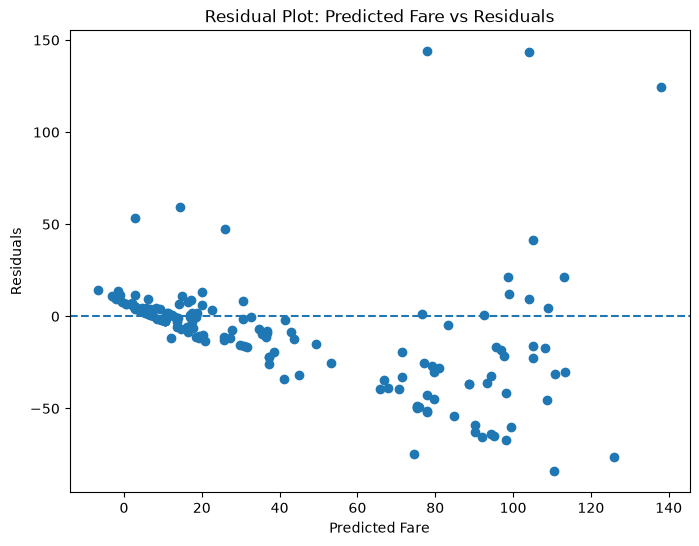

In [28]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(8, 6))

plt.scatter(y_reg_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot: Predicted Fare vs Residuals")

plt.show()

### Regression Results Interpretation

The multivariate linear regression model achieved an MAE of 18.72 and an RMSE of 30.85. The R² score of 0.385 indicates that the model explains approximately 38.5% of the variation in fare, while the Adjusted R² is 0.298.

From the residual plot, the residuals do not appear to have a completely random and constant spread around zero. The spread becomes larger for some higher predicted fare values, with several large residuals visible. This suggests the presence of heteroscedasticity, meaning the variance of the errors may not be constant.

In [30]:
import pandas as pd

# Final Model Comparison Table

final_comparison = pd.DataFrame({

    "Model Type": [
        "Classification",
        "Classification",
        "Classification",
        "Regression"
    ],

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Multivariate Linear Regression"
    ],

    # Classification Metrics
    "Accuracy": [
        0.832402,
        0.804469,
        0.826816,
        None
    ],

    "Precision": [
        0.809524,
        0.750000,
        0.787879,
        None
    ],

    "Recall": [
        0.739130,
        0.739130,
        0.753623,
        None
    ],

    "F1 Score": [
        0.772727,
        0.744526,
        0.770370,
        None
    ],

    "AUC": [
        0.868643,
        0.790580,
        0.836298,
        None
    ],

    # Regression Metrics
    "MAE": [
        None,
        None,
        None,
        18.724346
    ],

    "RMSE": [
        None,
        None,
        None,
        30.849712
    ],

    "R²": [
        None,
        None,
        None,
        0.384977
    ],

    "Adjusted R²": [
        None,
        None,
        None,
        0.298243
    ]
})

final_comparison

,Model Type,Model,Accuracy,Precision,Recall,F1 Score,AUC,MAE,RMSE,R²,Adjusted R²
0,Classification,Logistic Regression,0.832402,0.809524,0.739130,0.772727,0.868643,NaN,NaN,NaN,NaN
1,Classification,Decision Tree,0.804469,0.750000,0.739130,0.744526,0.790580,NaN,NaN,NaN,NaN
2,Classification,Random Forest,0.826816,0.787879,0.753623,0.770370,0.836298,NaN,NaN,NaN,NaN
3,Regression,Multivariate Linear Regression,NaN,NaN,NaN,NaN,NaN,18.724346,30.849712,0.384977,0.298243


## Final Model Recommendation

The classification and regression metrics are presented as separate metric groups because they measure different machine learning tasks and are not directly comparable on a single scale.

Among the three classifiers, Logistic Regression is recommended for deployment because it achieved the highest accuracy (0.8324) and the highest AUC (0.8686). It also achieved the highest precision (0.8095) and the highest F1 score (0.7727), showing the strongest overall classification performance.

Although Random Forest achieved a slightly higher recall (0.7536) than Logistic Regression (0.7391), Logistic Regression performed better overall in terms of accuracy, precision, and AUC. Therefore, Logistic Regression would be the preferred classifier for deployment based on its overall performance.

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import joblib

# Features and target
X_pipeline = df.drop(columns=["survived", "alive"])
y_pipeline = df["survived"]

# Numerical and categorical columns
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Complete end-to-end pipeline
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_pipeline),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit on training data only
full_pipeline.fit(X_train, y_train)

print("Complete pipeline created and trained successfully!")

Complete pipeline created and trained successfully!


In [32]:
import joblib

joblib.dump(full_pipeline, "best_model_pipeline.joblib")

print("Complete pipeline saved successfully!")

Complete pipeline saved successfully!


In [33]:
# Load the saved pipeline
loaded_pipeline = joblib.load("best_model_pipeline.joblib")

# Take raw, unprocessed test data
raw_sample = X_test.iloc[:5]

# Predict using the loaded pipeline
predictions = loaded_pipeline.predict(raw_sample)

print("Predictions from loaded pipeline:")
print(predictions)

Predictions from loaded pipeline:
[0 0 0 0 1]


### Model Pipeline Saving and Reloading

The complete machine learning pipeline, including preprocessing steps and the Logistic Regression classifier, was successfully saved using `joblib.dump()`. The saved pipeline was then reloaded using `joblib.load()` and tested on raw, unprocessed input data. The reloaded pipeline successfully generated predictions, confirming that the saved artifact can be used end-to-end for new raw data without requiring manual preprocessing.